### Gardient Desent when m is fixed

In [353]:
from sklearn.datasets import make_regression

import numpy as np

In [354]:
x,y=make_regression(n_samples=4,n_features=1,n_informative=1,n_targets=1,noise=80,random_state=13)

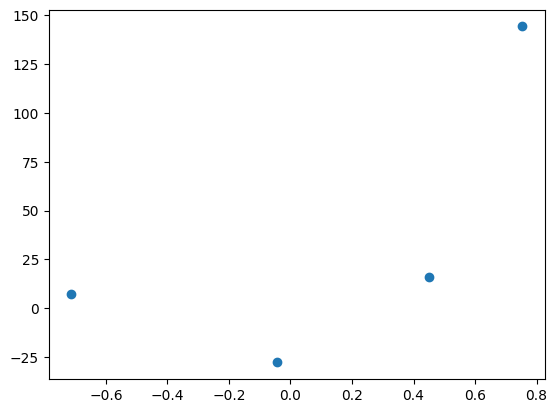

In [355]:
import matplotlib.pyplot as plt
plt.scatter(x,y)

In [356]:
# Lets apply OLS
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [357]:
lr.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[78.35]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,26.16
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1.11]


In [358]:
lr.coef_

array([78.35063668])

In [359]:
lr.intercept_

np.float64(26.15963284313262)

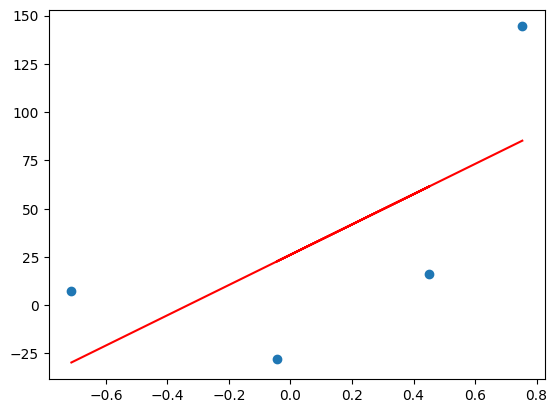

In [360]:
plt.scatter(x,y)
plt.plot(x,lr.predict(x),color="red")

In [361]:
# Lets apply Gradient descent assuming slope is constant m=78.35

#and lets assume the starting value for intercept b=0
y_pre=((78.35*x)+0).reshape(4)
y_pre

array([-55.81580837,  35.39949674,  -3.48681619,  59.05759577])

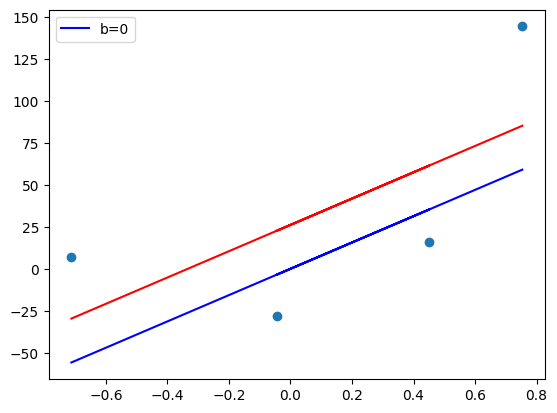

In [362]:
plt.scatter(x,y)
plt.plot(x,lr.predict(x),color="red")
plt.plot(x,y_pre,color="blue",label="b=0")
plt.legend()
plt.show()

In [363]:
m=78.35 #fix
b=0
loss_slope=-2*np.sum(y-m*x.ravel()-b)
loss_slope

np.float64(-209.27763408209216)

In [364]:
#lets take learning rate
lrr=0.1
step_size=loss_slope*lrr
step_size

np.float64(-20.927763408209216)

In [365]:
b

0

In [366]:

b=b-step_size
b

np.float64(20.927763408209216)

In [367]:
loss_slope=-2*np.sum(y-m*x.ravel()-b)
loss_slope

np.float64(-41.85552681641843)

In [368]:
#learnning rate
step_size=0.1*loss_slope

In [369]:
b=b-step_size
b

np.float64(25.11331608985106)

In [370]:
loss_slope=-2*np.sum(y-m*x.ravel()-b)
loss_slope

np.float64(-8.371105363283675)

In [371]:
b=b-0.1*loss_slope
b

np.float64(25.95042662617943)

In [372]:
loss_slope=-2*np.sum(y-m*x.ravel()-b)
b=b-0.1*loss_slope
b

np.float64(26.1178487334451)

In [373]:
loss_slope=-2*np.sum(y-m*x.ravel()-b)
b=b-0.1*loss_slope
b

np.float64(26.151333154898236)

In [374]:
loss_slope=-2*np.sum(y-m*x.ravel()-b)
b=b-0.1*loss_slope
b

np.float64(26.158030039188862)

In [375]:
b

np.float64(26.158030039188862)

In [376]:
y_pre=((78.35*x)+b).reshape(4)
y_pre

array([-29.65777833,  61.55752678,  22.67121385,  85.21562581])

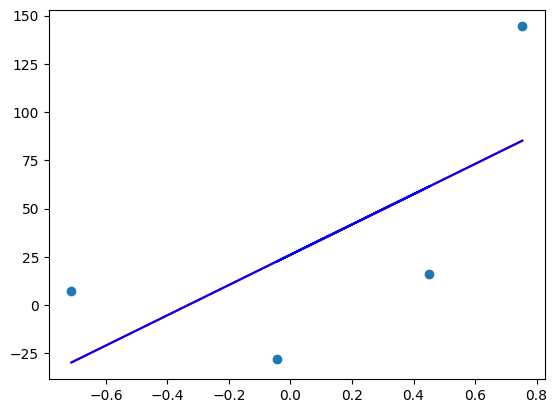

In [377]:
plt.scatter(x,y)
plt.plot(x,lr.predict(x),color="red")
plt.plot(x,y_pre,color="blue")

### Gradient Descent m or b both update with own class or without own class

#### without own class with sklearn

In [378]:
from sklearn.datasets import make_regression
x,y=make_regression(n_samples=100,n_features=1,n_targets=1,noise=13,n_informative=1,random_state=13)

In [379]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [380]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[27.94]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.476
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[8.7]


In [381]:
lr.coef_

array([27.94479063])

In [382]:
lr.intercept_

np.float64(-1.4761593770159478)

In [383]:
y_pred=lr.predict(x_test)
y_pred

array([ 21.74332526,  18.69900299,  18.90021704,  -7.27050328,
        16.40526428,  58.61584242, -14.15617467, -10.47783753,
       -14.92798281,  -7.97125171, -22.64303118,  15.4664502 ,
        13.39991146, -22.95528054, -21.38376727, -15.78291674,
        25.15049255, -16.09587383,  -3.08388991, -11.16201349])

In [385]:
from sklearn.metrics import r2_score
print("r2 score :",r2_score(y_test,y_pred))

r2 score : 0.8124623340107777


#### with own class

In [ ]:
import numpy as np
class Ml:
    def __init__(self,learning_rate,epochs):
        self.b=0
        self.m=0
        self.lr=learning_rate
        self.epochs=epochs
    def fit(self,x,y):
        #calculating the b Using GD
        n=len(x)
        for i in range(self.epochs):
            loss_slope_b=(-2/n)*np.sum(y-self.m*x.ravel()-self.b)
            loss_slope_m=(-2/n)*np.sum((y-self.m*x.ravel()-self.b)*x.ravel())

            self.b=self.b-(self.lr*loss_slope_b)
            self.m=self.m-(self.lr*loss_slope_m)
        print(self.m,self.b)

    def predict(self,x):
        y_pre=self.m*x.ravel()+self.b
        return y_pre

    

In [ ]:
gd=Ml(0.1,30)
gd.fit(x,y)

27.655387892891223 -1.4641472151971477


In [ ]:
gd.predict(x)

array([-21.16558731, -13.55357989, -14.01284533,  24.88675293,
         5.11390357,  22.3529874 ,  -8.1934291 ,   3.65060478,
       -21.40367285, -13.35311777,  54.26756639,   9.52171575,
         4.28264386,  -7.89197486, -22.72082562,  11.06813001,
        16.23209227,   8.47885788, -46.13058443,  46.91181301,
       -23.28394474, -15.62274048, -27.13761798,  58.00552787,
        -7.19848355, -46.79391129, -10.82876638, -10.3726019 ,
       -14.77666044, -15.93245651,  18.50207649,  19.71741994,
        11.07704686, -36.354349  , -61.94966846, -34.2473642 ,
         4.54956277,  35.32628333, -31.53057582,  14.08541836,
       -43.3024657 ,  -1.53021664,  -9.15606516,  11.03089827,
        31.46526896,  24.04363798,  21.07486789, -18.63758176,
        23.80570641,  30.01689476,  39.42948043, -19.46936668,
       -11.86035956, -22.88767092,  12.39499906,  35.87582288,
        18.70120671,  -3.72225267, -25.08580191,  11.41380463,
        -2.69489711,  -3.05522772,  50.88037303, -30.37

In [386]:
y_pred=gd.predict(x_test)
from sklearn.metrics import r2_score
print("r2 score :",r2_score(y_test,y_pred))

r2 score : 0.8133849841883566
